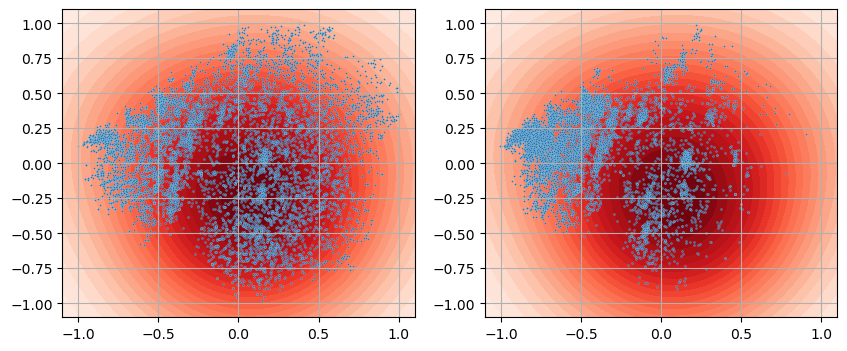

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np
import pickle

from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')

def calc_fps(smis, fp_func):
    fps = [fp_func(Chem.MolFromSmiles(smi)) for smi in smis]
    return fps

def fit_decomp_kde(fps_train, pipe, kde):
    
    X_train_decomp = pipe.fit_transform(fps_train)
    kde.fit(X_train_decomp)
    
    return X_train_decomp

def plot_decomp_kde(X_decomp, kde, ax):
        
    X, Y = np.meshgrid(np.linspace(-1.1, 1.1, 100), np.linspace(-1.1, 1.1, 100))
    Z = np.vstack([Y.ravel(), X.ravel()]).T
    # density at gridpoints
    Z = np.exp(kde.score_samples(Z)).reshape(100,100)

    # kernel density countour plot
    levels = np.linspace(0, Z.max(), 25)
    m = ax.contourf(X, Y, Z, levels=levels, cmap=plt.cm.Reds)
    sns.scatterplot(x=X_decomp[:, 0], y=X_decomp[:, 1], s=2, ax=ax)

    ax.grid(True)
    
    return X_decomp


kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
pipe = Pipeline([('decomp', PCA(n_components=2)), ('scaler', MinMaxScaler((-1,1)))])

fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2).GetFingerprint

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

smis_train = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/PCCP/hydros8992.smi").readlines()]
fps_train = calc_fps(smis_train, fpgen)
X_train_decomp = fit_decomp_kde(fps_train, pipe, kde)
plot_decomp_kde(X_train_decomp, kde, ax[0])

smis_test = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/scratch_programs/random_mol_gen/results_01_09_25/10k_random_gen.smi").readlines()]
fps_test = calc_fps(smis_test, fpgen)
X_test_decomp = pipe.transform(fps_test)
plot_decomp_kde(X_test_decomp, kde, ax[1])
plt.show()

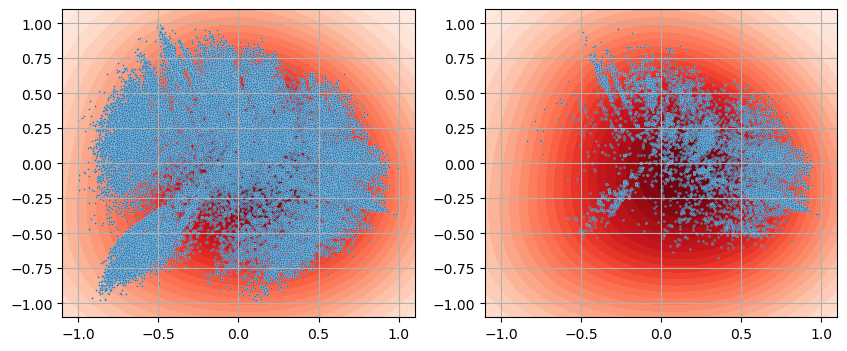

In [31]:
kde = KernelDensity(kernel="gaussian", bandwidth=0.5)
pipe = Pipeline([('decomp', PCA(n_components=2)), ('scaler', MinMaxScaler((-1,1)))])

fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2).GetFingerprint

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

smis_train = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/combined_set.smi").readlines()]
fps_train = calc_fps(smis_train, fpgen)
X_train_decomp = fit_decomp_kde(fps_train, pipe, kde)
plot_decomp_kde(X_train_decomp, kde, ax[0])

smis_test = [i.rstrip() for i in open("/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/data/HCs/PCCP/hydros8992.smi").readlines()]
fps_test = calc_fps(smis_test, fpgen)
X_test_decomp = pipe.transform(fps_test)
plot_decomp_kde(X_test_decomp, kde, ax[1])
plt.show()

In [44]:
import pickle

# load pipe and kde
pipedir = "/home/andyt/DProjects/DMCTS/VINA_ChemTSv2/result/notebooks/HCs/clustering_for_mol_fingerprints/fp_candidates_scripts/selected_candidates_RNN_random_generated"

with open(f"{pipedir}/morgan_PCA_pipe.pkl", "rb") as rb:
    pipe = pickle.load(rb)
    
with open(f"{pipedir}/morgan_PCA_kde.pkl", "rb") as rb:
    kde = pickle.load(rb)

/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/andyt/miniconda3/envs/regression_sandbox/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipe